<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import zipfile
import os
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneOut, cross_val_score
from IPython.display import clear_output

sns.set(style='darkgrid', font_scale=1.2)

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [3]:
def get_dataloader(data_dir, image_size, batch_size, stats):

    """
    Builds dataloader for training data.
    Use tt.Compose and tt.Resize for transformations
    :param image_size: height and wdith of the image
    :param batch_size: batch_size of the dataloader
    :returns: DataLoader object
    """
    # TODO: resize images, convert them to tensors and build dataloader
    data = ImageFolder(DATA_DIR, transform=tt.Compose([tt.Resize(image_size),
                                                       tt.CenterCrop(image_size),
                                                       tt.ToTensor(),
                                                       tt.Normalize(*stats)]))

    dl = DataLoader(data, batch_size, shuffle=True, num_workers=2, pin_memory=True)

    return dl



In [4]:
image_size = 128

#TODO: build dataloader and transfer it to device

In [5]:
def denorm(img_tensors):
    return img_tensors * stats[1][0] + stats[0][0]

def show_images(images, nmax=64):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    # Added .cpu() to move the tensor to host memory for matplotlib
    ax.imshow(make_grid(denorm(images.detach()[:nmax].cpu()), nrow=8).permute(1, 2, 0))

def show_batch(dl, nmax=64):
    for images, _ in dl:
        show_images(images, nmax)
        break

In [6]:
!gdown 1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x -O dataset.zip

Downloading...
From (original): https://drive.google.com/uc?id=1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x
From (redirected): https://drive.google.com/uc?id=1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x&confirm=t&uuid=ed9fd2a1-f7db-47ee-a849-c62c1eca0889
To: /kaggle/working/dataset.zip
100%|███████████████████████████████████████| 4.28G/4.28G [00:39<00:00, 108MB/s]


In [7]:
# Path to the zip file already present in the environment
zip_path = 'dataset.zip'
extract_path = './faces_dataset_small/'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Successfully extracted {zip_path} to {extract_path}")
    print("Contents:", os.listdir(extract_path))
else:
    print(f"Error: {zip_path} not found. Please upload the dataset or provide the correct path.")

Successfully extracted dataset.zip to ./faces_dataset_small/
Contents: ['faces_dataset_small']


In [8]:
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [9]:
DATA_DIR = './faces_dataset_small/'
image_size = 128
batch_size = 128
stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

# Initialize the basic dataloader
train_dl_raw = get_dataloader(DATA_DIR, image_size, batch_size, stats)

# Wrap it with the DeviceDataLoader for GPU support
train_dl = DeviceDataLoader(train_dl_raw, device)

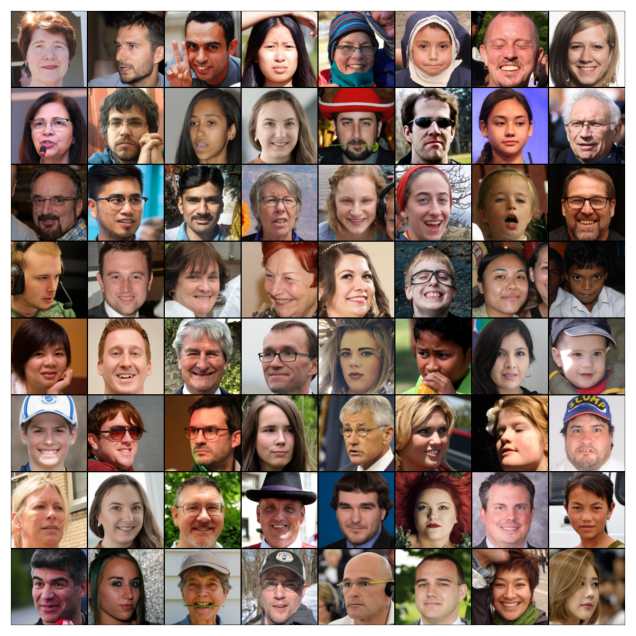

In [10]:
show_batch(train_dl)

In [11]:
train_dl = DeviceDataLoader(train_dl, device)

In [12]:
next(iter(train_dl))[0].shape

torch.Size([128, 3, 128, 128])

## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [13]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(nn.Conv2d(3, 128, kernel_size=4, stride=2, padding=1, bias=False),
                                   nn.BatchNorm2d(128),
                                   nn.LeakyReLU(0.2, inplace=True))
        self.conv2 = nn.Sequential(nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
                                   nn.BatchNorm2d(256),
                                   nn.LeakyReLU(0.2, inplace=True))
        self.conv3 = nn.Sequential(nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
                                   nn.BatchNorm2d(512),
                                   nn.LeakyReLU(0.2, inplace=True))
        self.conv4 = nn.Sequential(nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
                                   nn.BatchNorm2d(512),
                                   nn.LeakyReLU(0.2, inplace=True))
        self.conv4 = nn.Sequential(nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1, bias=False),
                                   nn.BatchNorm2d(1024),
                                   nn.LeakyReLU(0.2, inplace=True))

        self.conv5 = nn.Conv2d(1024, 1, kernel_size=4, stride=1, padding=0, bias=False)
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(5*5,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
#        print(x.shape) # [128, 3, 128, 128]
        x = self.conv1(x)
#        print(x.shape) # [128, 128, 64, 64]
        x = self.conv2(x)
#        print(x.shape) # [128, 256, 32, 32]
        x = self.conv3(x)
#        print(x.shape) # [128, 512, 16, 16]
        x = self.conv4(x)
#        print(x.shape) # [128, 1024, 8, 8]
        x = self.conv5(x)
#        print(x.shape) # [128, 1, 5, 5]
        x = self.flatten(x)
#        print(x.shape) # [128, 25]
        x = self.linear(x)
#        print(x.shape) # [128, 1]
        x = self.sigmoid(x)
#        print(x.shape) # [128, 1]

        return x



In [14]:
class Generator(nn.Module):
    def __init__(self, latent_size):
        super().__init__()

        self.dconv1 = nn.Sequential(nn.ConvTranspose2d(latent_size, 1024, kernel_size=4, stride=1, padding=0, bias=False),
                                    nn.BatchNorm2d(1024),
                                    nn.ReLU(True))
        self.dconv2 = nn.Sequential(nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1, bias=False),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU(True))
        self.dconv3 = nn.Sequential(nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU(True))
        self.dconv4 = nn.Sequential(nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU(True))
        self.dconv5 = nn.Sequential(nn.ConvTranspose2d(128, 3, kernel_size=4, stride=4, padding=0, bias=False),
                                    nn.Tanh())

    def forward(self, x):
#        print(x.shape) # [128, 512, 1, 1]
        x = self.dconv1(x)
#        print(x.shape) # [128, 1024, 4, 4]
        x = self.dconv2(x)
#        print(x.shape) # [128, 512, 8, 8]
        x = self.dconv3(x)
#        print(x.shape) # [128, 256, 16, 16]
        x = self.dconv4(x)
#        print(x.shape) # [128, 128, 32, 32]
        x = self.dconv5(x)
#        print(x.shape) # [128, 3, 128, 128]

        return x


In [15]:
latent_size = 640
discriminator = Discriminator().to(device)
generator = Generator(latent_size).to(device)

In [ ]:
xb = torch.randn(batch_size, latent_size, 1, 1).to(device)
fake_images = generator(xb)
print(fake_images.shape)
show_images(fake_images)

In [17]:
fixed_latent = torch.randn(batch_size, latent_size, 1, 1, device=device)

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [18]:
lr = 2e-4
epochs = 150 #10

model = {
    "discriminator": discriminator.to(device),
    "generator": generator.to(device)
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

In [19]:
def fit(model, criterion, epochs, lr, device):
    # Ensure models are on the correct device
    model["discriminator"] = model["discriminator"].to(device)
    model["generator"] = model["generator"].to(device)

    model["discriminator"].train()
    model["generator"].train()
    torch.cuda.empty_cache()

    # Losses & scores
    losses = {'discriminator':[], 'generator':[]}
    scores = {'real':[], 'fake':[]}

    # Create optimizers
    optimizer = {
        "discriminator": torch.optim.Adam(model["discriminator"].parameters(), lr=lr, betas=(0.5, 0.999)),
        "generator": torch.optim.Adam(model["generator"].parameters(), lr=lr, betas=(0.5, 0.999))}
    # Create scheduler
    scheduler = {
        "discriminator": torch.optim.lr_scheduler.StepLR(optimizer["discriminator"], step_size=25, gamma=0.1),
        "generator": torch.optim.lr_scheduler.StepLR(optimizer["generator"], step_size=25, gamma=0.1)}

    # Progress bar for epochs
    for epoch in tqdm(range(epochs), desc="Training GAN"):
        loss_d_per_epoch = []
        loss_g_per_epoch = []
        real_score_per_epoch = []
        fake_score_per_epoch = []

        for real_images, _ in train_dl:
            # Train discriminator
            optimizer["discriminator"].zero_grad()

            real_preds = model["discriminator"](real_images)
            real_targets = torch.ones(real_images.size(0), 1, device=device)
            real_loss = criterion["discriminator"](real_preds, real_targets)
            cur_real_score = torch.mean(real_preds).item()

            latent = torch.randn(real_images.size(0), latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)
            fake_targets = torch.zeros(fake_images.size(0), 1, device=device)
            fake_preds = model["discriminator"](fake_images.detach())
            fake_loss = criterion["discriminator"](fake_preds, fake_targets)
            cur_fake_score = torch.mean(fake_preds).item()

            real_score_per_epoch.append(cur_real_score)
            fake_score_per_epoch.append(cur_fake_score)

            loss_d = real_loss + fake_loss
            loss_d.backward()
            optimizer["discriminator"].step()
            loss_d_per_epoch.append(loss_d.item())

            # Train generator
            optimizer["generator"].zero_grad()
            preds = model["discriminator"](fake_images)
            targets = torch.ones(fake_images.size(0), 1, device=device)
            loss_g = criterion["generator"](preds, targets)

            loss_g.backward()
            optimizer["generator"].step()
            loss_g_per_epoch.append(loss_g.item())

        # Record metrics
        losses['generator'].append(np.mean(loss_g_per_epoch))
        losses['discriminator'].append(np.mean(loss_d_per_epoch))
        scores['real'].append(np.mean(real_score_per_epoch))
        scores['fake'].append(np.mean(fake_score_per_epoch))

        scheduler["discriminator"].step()
        scheduler["generator"].step()

        if (epoch + 1) % 5 == 0:
            #clear_output(wait=True)
            print(f"Epoch [{epoch+1}/{epochs}], loss_g: {losses['generator'][-1]:.4f}, loss_d: {losses['discriminator'][-1]:.4f}, real_score: {scores['real'][-1]:.4f}, fake_score: {scores['fake'][-1]:.4f}")
            xb = torch.randn(64, latent_size, 1, 1, device=device)
            sample_images = model['generator'](xb)
            show_images(sample_images)
            plt.show()

    return losses, scores

In [20]:
def history_plot(history):

    history_loss = history[0]
    history_scores = history[1]

    fig, ax = plt.subplots(1,2, figsize=(16, 6))
    ax[0].plot(history_loss['generator'], label=f"Generator loss",color='blue')
    ax[0].plot(history_loss['discriminator'], label=f"Discriminator loss",color='orange')
    ax[0].legend(loc='upper right', fontsize='xx-small')
    ax[0].set_xlabel('epochs')
    ax[0].set_ylabel("loss")

    ax[1].plot(history_scores['real'], label=f"Real score",color='blue')
    ax[1].plot(history_scores['fake'], label=f"Fake score",color='orange')
    ax[1].legend(loc='upper right', fontsize='xx-small')
    ax[1].set_xlabel('epochs')
    ax[1].set_ylabel("scores")

    fig.suptitle(f"History of training")

    plt.show()

In [ ]:
history = fit(model, criterion, epochs, lr, device)

In [ ]:
'''Epoch [5/150], loss_g: 7.5832, loss_d: 0.1002, real_score: 0.9798, fake_score: 0.0641
другого способа убрать картинки нет
Epoch [150/150], loss_g: 3.3522, loss_d: 0.1007, real_score: 0.9509, fake_score: 0.0437'''

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [22]:
n_images = 32

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent).cpu()

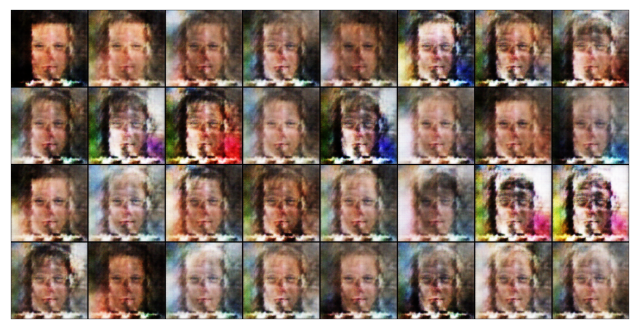

In [23]:
def show_images_additional(images, n_images):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach()), nrow=8).permute(1, 2, 0))
show_images(fake_images, n_images)

Как вам качество получившихся изображений? Оценил. Bruh.

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [24]:
size_of_analysis = 500

fixed_latent = torch.randn(size_of_analysis, latent_size, 1, 1, device=torch.device('cuda'))
fake_images = model["generator"](fixed_latent)
fake_images = fake_images.detach().cpu().flatten(start_dim=1)

In [25]:
dl_analysis = get_dataloader(DATA_DIR, image_size, size_of_analysis, stats)

for real_images, _ in dl_analysis:
    # Move to device to match fake_images
    real_images = real_images.to(device)
    break

real_images = real_images.flatten(start_dim=1)

In [26]:
print(fake_images.shape, real_images.shape)

torch.Size([500, 49152]) torch.Size([500, 49152])


In [27]:
# Move both to CPU to ensure consistency for scikit-learn
X_train = torch.cat((fake_images.cpu(), real_images.cpu()))

y_fake = torch.ones(fake_images.shape[0])
y_real = torch.zeros(real_images.shape[0])
y_train = torch.cat((y_fake, y_real))

In [28]:
knn = KNeighborsClassifier(n_neighbors=1)
loo = LeaveOneOut()

In [29]:
%%time

# Получим кросс-валидационный Accuracy
scores = cross_val_score(knn, X_train, y_train, scoring='accuracy', cv=loo, n_jobs=-1)

# Выведем среднее значение Accuracy по фолдам
scores.mean()

CPU times: user 2min 38s, sys: 5min 58s, total: 8min 36s
Wall time: 14min 5s


np.float64(0.914)

Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему? Ну это явно маловато

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

In [30]:
n_clusters = 2

tsne = TSNE(n_clusters, n_jobs=-1)
tsne_result = tsne.fit_transform(X_train)
tsne_result.shape

(1000, 2)

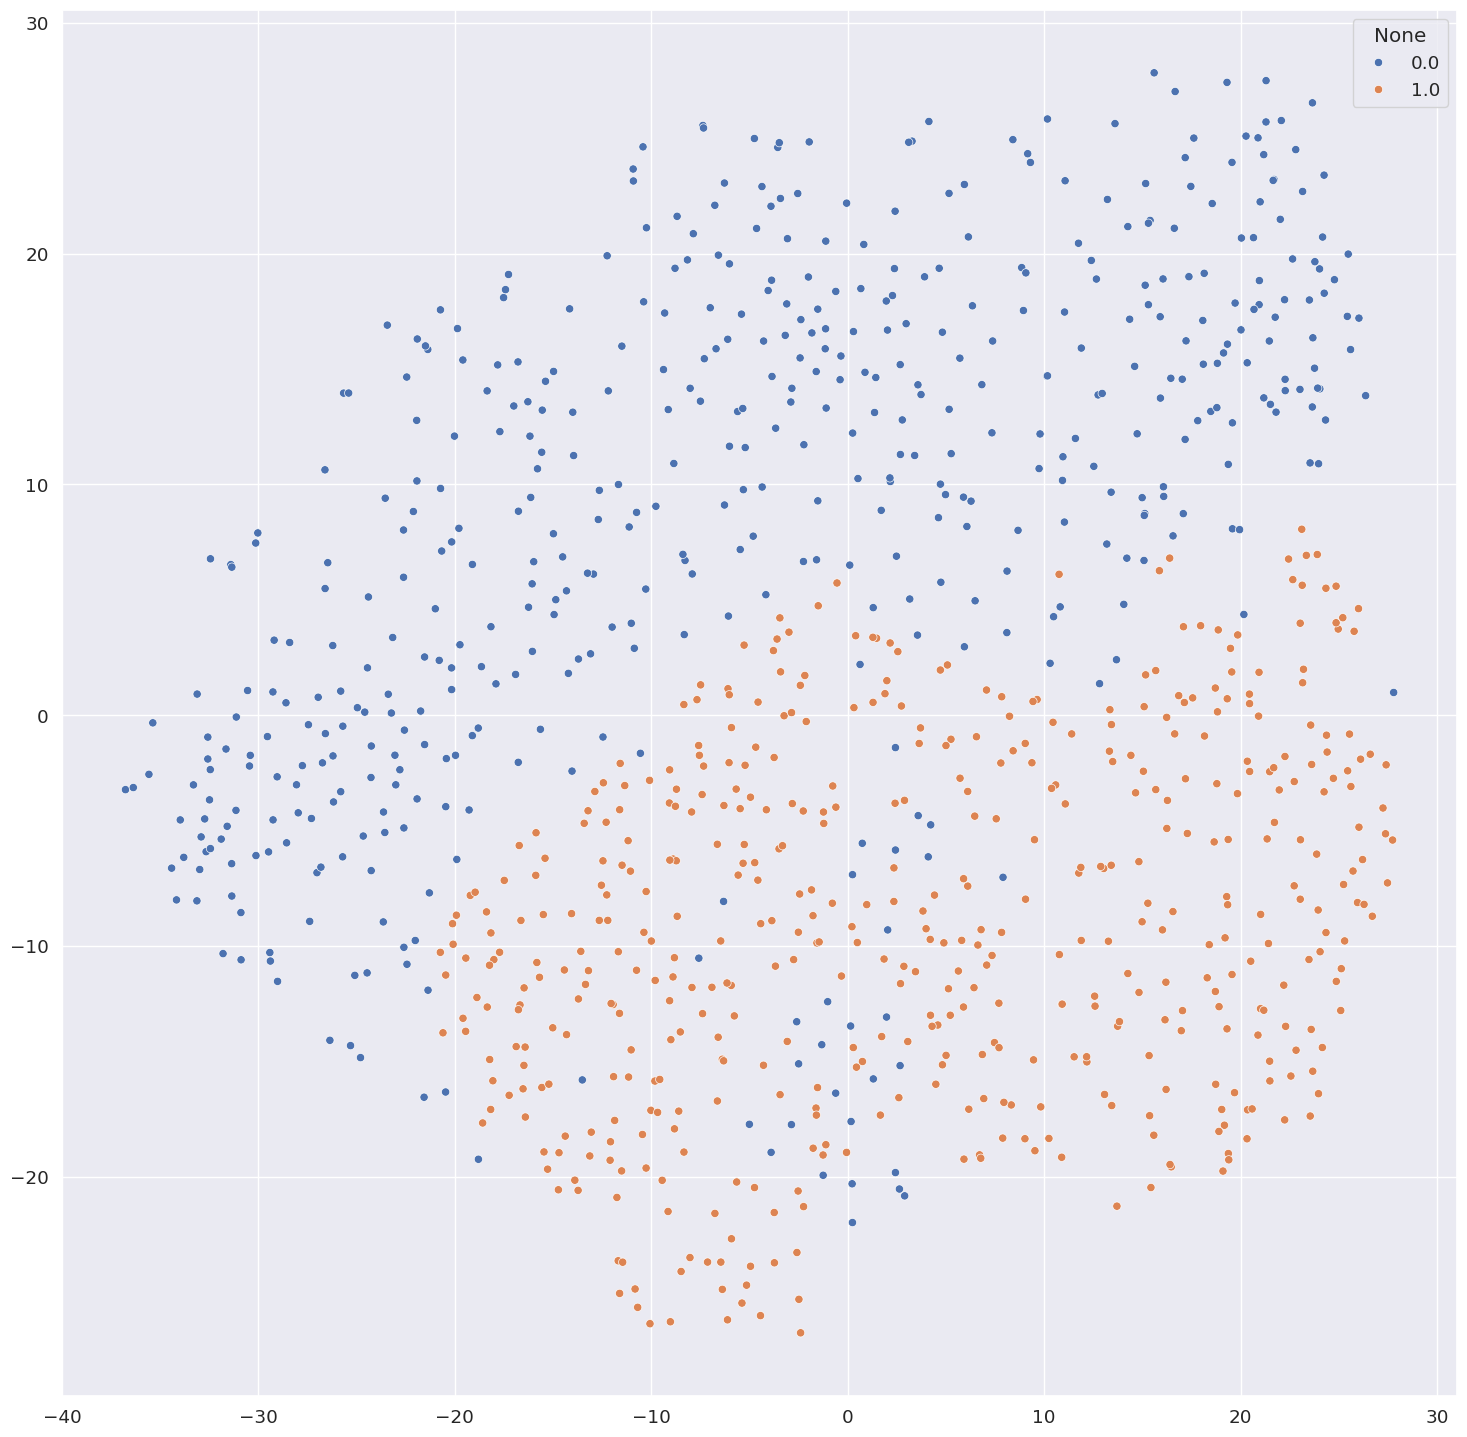

In [31]:
plt.figure(figsize=(18, 18))
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=y_train)
plt.show()

Прокомментируйте получившийся результат:  разделилось